# DAC-Based Lens Column Inversion (JEOL ARM-200F)

## Goal
Recover the physical column parameters (inter-lens distances $d_i$, focal-length
coefficients $\tilde{C}_{f,i}$, and rotation constants $\tilde{K}_i$) from the
manufacturer's **magnification → DAC look-up table**.

## Column layout (OL image plane → detector)

$$\text{OL image} \xrightarrow{d_0} \text{IL1} \xrightarrow{d_1} \text{IL2} \xrightarrow{d_2} \text{IL3} \xrightarrow{d_3} \text{PL1} \xrightarrow{d_4} \text{detector}$$

## Model
- Focal length: $f_i = 1/(\tilde{C}_{f,i} \cdot \text{DAC}_i^2)$  where DAC is proportional to current
- Rotation: $\psi_i = \tilde{K}_i \cdot \text{DAC}_i$  (linear in current)
- Zero total rotation at every calibrated magnification: $\sum_i \tilde{K}_i \cdot \text{DAC}_i^{(m)} = 0$
- Magnification: $|A^{(m)}| = |M_{00}|$ from the ABCD matrix product

## Strategy
1. **Stage 1** – Solve rotation equations (linear least-squares) → $\tilde{K}_i$
2. **Stage 2** – Fit nonlinear ABCD model for distances and $\tilde{C}_{f,i}$
3. **Cross-mode** – Combine data from all operating modes
4. **Validate** – Synthetic round-trip test, residual analysis, physical reasonableness

In [2]:
import sys
sys.path.insert(0, "../../src")

import numpy as np
import jax
import jax.numpy as jnp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

from temgym_core.transfer_matrices import propagation_matrix, lens_matrix

jax.config.update("jax_enable_x64", True)

# ================================================================
# RAW DAC DATA — JEOL ARM-200F magnification look-up table
# Keys: magnification (string), values: dict of lens DAC hex values
# ================================================================
RAW_DAC_HEX = {
    "2000":    {"IL1": "0x4b4b", "IL2": "0x4b2b", "IL3": "0xaf98", "OLf": "0x625a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "2500":    {"IL1": "0x4cd7", "IL2": "0x458f", "IL3": "0xb471", "OLf": "0x562a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "3000":    {"IL1": "0x4e0b", "IL2": "0x4046", "IL3": "0xb8fd", "OLf": "0x582a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "4000":    {"IL1": "0x4fcf", "IL2": "0x3657", "IL3": "0xc0d7", "OLf": "0x656a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "5000":    {"IL1": "0x512f", "IL2": "0x2d1d", "IL3": "0xc719", "OLf": "0x6d6a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "6000":    {"IL1": "0x526e", "IL2": "0x2515", "IL3": "0xcccc", "OLf": "0x684a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "8000":    {"IL1": "0x6a31", "IL2": "0x607f", "IL3": "0xadd0", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xe2cb"},
    "10000":   {"IL1": "0x6fe4", "IL2": "0x5c11", "IL3": "0xb1c7", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xe5a6"},
    "12000":   {"IL1": "0x73f5", "IL2": "0x5925", "IL3": "0xb6fe", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xeb2f"},
    "15000":   {"IL1": "0x7830", "IL2": "0x56ad", "IL3": "0xc026", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xf548"},
    "20000":   {"IL1": "0x8057", "IL2": "0x52d6", "IL3": "0xbeb9", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xf9bb"},
    "25000":   {"IL1": "0x8692", "IL2": "0x50e2", "IL3": "0x9b35", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xffff"},
    "30000":   {"IL1": "0x9f22", "IL2": "0x611e", "IL3": "0x9b35", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "40000":   {"IL1": "0xa336", "IL2": "0x611e", "IL3": "0x8ad8", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "50000":   {"IL1": "0xa674", "IL2": "0x6498", "IL3": "0x85b7", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "60000":   {"IL1": "0xa810", "IL2": "0x6a48", "IL3": "0x7f59", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "80000":   {"IL1": "0xa8ea", "IL2": "0x7182", "IL3": "0x77d2", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "100000":  {"IL1": "0xa800", "IL2": "0x7d46", "IL3": "0x7205", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "120000":  {"IL1": "0xa7d4", "IL2": "0x7d46", "IL3": "0x6c7f", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "150000":  {"IL1": "0xa761", "IL2": "0x8431", "IL3": "0x65e6", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "200000":  {"IL1": "0xa6c5", "IL2": "0x957b", "IL3": "0x5c4a", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "250000":  {"IL1": "0xa6a8", "IL2": "0x957b", "IL3": "0x552b", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "300000":  {"IL1": "0xa608", "IL2": "0x9ec6", "IL3": "0x4ba8", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "400000":  {"IL1": "0xa584", "IL2": "0xad0c", "IL3": "0x3e16", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "500000":  {"IL1": "0xa51d", "IL2": "0xb944", "IL3": "0x3268", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "600000":  {"IL1": "0xa4d0", "IL2": "0xc3c7", "IL3": "0x2771", "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "800000":  {"IL1": "0xe300", "IL2": "0xe54f", "IL3": "0x478",  "OLf": "0x990a", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "1000000": {"IL1": "0xe300", "IL2": "0xbd3a", "IL3": "0x1ac9", "OLf": "0x93ca", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "1200000": {"IL1": "0xe300", "IL2": "0xcd09", "IL3": "0x1ac9", "OLf": "0x93ca", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "1500000": {"IL1": "0xe300", "IL2": "0xec00", "IL3": "0x0",   "OLf": "0x93ca", "OLc": "0xb2fa", "PL1": "0xfa00"},
    "2000000": {"IL1": "0xffff", "IL2": "0xf800", "IL3": "0x0",   "OLf": "0x93ca", "OLc": "0xb2fa", "PL1": "0xfa00"},
}

# ================================================================
# Parse into structured arrays
# ================================================================
LENS_NAMES = ["IL1", "IL2", "IL3", "PL1"]  # imaging lenses in column order
AUX_NAMES  = ["OLf", "OLc"]                # OL coils (not independent lenses)

def parse_dac_table(raw):
    """Convert hex DAC table -> dict of arrays, assign operating mode labels."""
    mags = sorted(int(k) for k in raw.keys())
    n = len(mags)

    data = {
        "mag": np.array(mags, dtype=float),
        "log_mag": np.log10(mags),
    }
    for lens in LENS_NAMES + AUX_NAMES:
        data[lens] = np.array([int(raw[str(m)][lens], 16) for m in mags], dtype=float)

    # Assign operating modes based on OLf / PL1 transitions
    # Mode A: 2k-6k   (OLf variable, PL1 = 64000)
    # Mode B: 8k-25k  (OLf = 39178, PL1 variable)
    # Mode C: 30k-600k (OLf = 39178, PL1 = 64000) -- cleanest
    # Mode D: 800k-2M  (OLf variable, PL1 = 64000, IL3 near zero)
    modes = []
    for m in mags:
        if m <= 6000:
            modes.append("A")
        elif m <= 25000:
            modes.append("B")
        elif m <= 600000:
            modes.append("C")
        else:
            modes.append("D")
    data["mode"] = np.array(modes)

    return data

dac = parse_dac_table(RAW_DAC_HEX)

# ================================================================
# Display summary table
# ================================================================
print(f"{'Mag':>10s} {'Mode':>4s} {'IL1':>7s} {'IL2':>7s} {'IL3':>7s} "
      f"{'PL1':>7s} {'OLf':>7s} {'IL2+IL3':>8s}")
print("-" * 65)
for i, m in enumerate(dac["mag"]):
    il1 = dac["IL1"][i]; il2 = dac["IL2"][i]; il3 = dac["IL3"][i]
    pl1 = dac["PL1"][i]; olf = dac["OLf"][i]
    print(f"{m:>10.0f} {dac['mode'][i]:>4s} {il1:>7.0f} {il2:>7.0f} "
          f"{il3:>7.0f} {pl1:>7.0f} {olf:>7.0f} {il2+il3:>8.0f}")

# Mode C statistics
mask_c = dac["mode"] == "C"
s23 = dac["IL2"][mask_c] + dac["IL3"][mask_c]
print(f"\n--- Mode C ({mask_c.sum()} settings) ---")
print(f"  IL2+IL3: mean={np.mean(s23):.0f}, std={np.std(s23):.0f} "
      f"({np.std(s23)/np.mean(s23)*100:.2f}%)")
print(f"  IL1: mean={np.mean(dac['IL1'][mask_c]):.0f}, "
      f"std={np.std(dac['IL1'][mask_c]):.0f} "
      f"({np.std(dac['IL1'][mask_c])/np.mean(dac['IL1'][mask_c])*100:.2f}%)")

       Mag Mode     IL1     IL2     IL3     PL1     OLf  IL2+IL3
-----------------------------------------------------------------
      2000    A   19275   19243   44952   64000   25178    64195
      2500    A   19671   17807   46193   64000   22058    64000
      3000    A   19979   16454   47357   64000   22570    63811
      4000    A   20431   13911   49367   64000   25962    63278
      5000    A   20783   11549   50969   64000   28010    62518
      6000    A   21102    9493   52428   64000   26698    61921
      8000    B   27185   24703   44496   58059   39178    69199
     10000    B   28644   23569   45511   58790   39178    69080
     12000    B   29685   22821   46846   60207   39178    69667
     15000    B   30768   22189   49190   62792   39178    71379
     20000    B   32855   21206   48825   63931   39178    70031
     25000    B   34450   20706   39733   65535   39178    60439
     30000    C   40738   24862   39733   64000   39178    64595
     40000    C   41782 

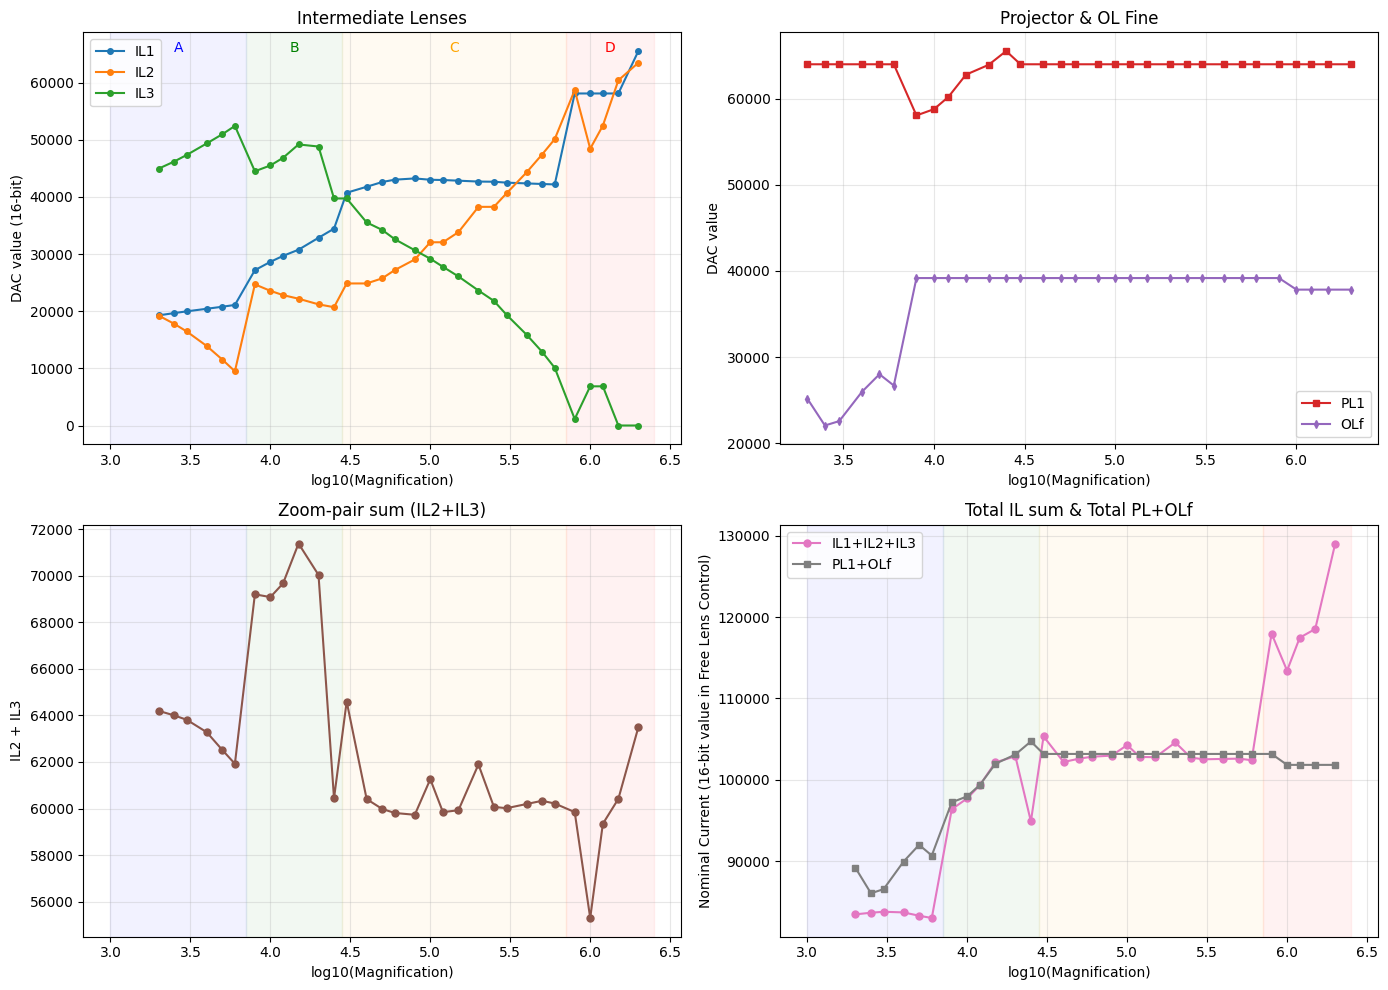

In [8]:
# ================================================================
# Visualize DAC curves vs magnification
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: All IL lenses
ax = axes[0, 0]
for lens, color in zip(["IL1","IL2","IL3"], ["C0","C1","C2"]):
    ax.plot(dac["log_mag"], dac[lens], "o-", label=lens, color=color, markersize=4)
ax.set_xlabel("log10(Magnification)")
ax.set_ylabel("DAC value (16-bit)")
ax.set_title("Intermediate Lenses")
ax.legend()
ax.grid(True, alpha=0.3)
# Shade mode regions
for mode, lo, hi, c in [("A",3.0,3.85,"blue"),("B",3.85,4.45,"green"),
                          ("C",4.45,5.85,"orange"),("D",5.85,6.4,"red")]:
    ax.axvspan(lo, hi, alpha=0.05, color=c)
    ax.text((lo+hi)/2, ax.get_ylim()[1]*0.95, mode, ha="center", fontsize=10, color=c)

# Panel 2: PL1 and OLf
ax = axes[0, 1]
ax.plot(dac["log_mag"], dac["PL1"], "s-", label="PL1", color="C3", markersize=4)
ax.plot(dac["log_mag"], dac["OLf"], "d-", label="OLf", color="C4", markersize=4)
ax.set_xlabel("log10(Magnification)")
ax.set_ylabel("DAC value")
ax.set_title("Projector & OL Fine")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 3: IL2+IL3 sum
ax = axes[1, 0]
s23 = dac["IL2"] + dac["IL3"]
ax.plot(dac["log_mag"], s23, "o-", color="C5", markersize=5)
ax.set_xlabel("log10(Magnification)")
ax.set_ylabel("IL2 + IL3")
ax.set_title("Zoom-pair sum (IL2+IL3)")
ax.grid(True, alpha=0.3)
for mode, lo, hi, c in [("A",3.0,3.85,"blue"),("B",3.85,4.45,"green"),
                          ("C",4.45,5.85,"orange"),("D",5.85,6.4,"red")]:
    ax.axvspan(lo, hi, alpha=0.05, color=c)

# Panel 4: IL1+IL2+IL3 total
ax = axes[1, 1]
total = dac["IL1"] + dac["IL2"] + dac["IL3"]
total_pl_obj = dac["PL1"] + dac["OLf"]
ax.plot(dac["log_mag"], total, "o-", color="C6", markersize=5, label="IL1+IL2+IL3")
ax.plot(dac["log_mag"], total_pl_obj, "s-", color="C7", markersize=5, label="PL1+OLf")
ax.set_xlabel("log10(Magnification)")
ax.set_ylabel('Nominal Current (16-bit value in Free Lens Control)')
ax.set_title("Total IL sum & Total PL+OLf")
ax.grid(True, alpha=0.3)
plt.legend()
for mode, lo, hi, c in [("A",3.0,3.85,"blue"),("B",3.85,4.45,"green"),
                          ("C",4.45,5.85,"orange"),("D",5.85,6.4,"red")]:
    ax.axvspan(lo, hi, alpha=0.05, color=c)

plt.tight_layout()
plt.show()

## Forward Model

Given the column layout:
$$\text{OL image} \xrightarrow{d_0} \text{IL1} \xrightarrow{d_1} \text{IL2} \xrightarrow{d_2} \text{IL3} \xrightarrow{d_3} \text{PL1} \xrightarrow{d_4} \text{detector}$$

The system matrix is (composed right-to-left):
$$M = P(d_4) \cdot L_{\text{PL1}} \cdot P(d_3) \cdot L_{\text{IL3}} \cdot P(d_2) \cdot L_{\text{IL2}} \cdot P(d_1) \cdot L_{\text{IL1}} \cdot P(d_0)$$

With $N_\text{lenses} = 4$ lenses and $N_\text{dists} = 5$ drift distances.

**Focal length model** (DAC-based):
$$f_i = \frac{1}{\tilde{C}_{f,i} \cdot \text{DAC}_i^2}$$

**Rotation model** (zero total rotation at calibrated settings):
$$\psi_\text{total}^{(m)} = \sum_i \tilde{K}_i \cdot \text{DAC}_i^{(m)} = 0$$

In [2]:
# ================================================================
# FORWARD MODEL (JAX-differentiable)
# ================================================================

N_LENSES = 4   # IL1, IL2, IL3, PL1
N_DISTS  = 5   # d0..d4

def build_abcd(dists, focals, xp=jnp):
    """Build system ABCD matrix from distances and focal lengths.
    
    dists:  array of shape (N_LENSES+1,) = [d0, d1, d2, d3, d4]
    focals: array of shape (N_LENSES,)   = [f_IL1, f_IL2, f_IL3, f_PL1]
    """
    M = propagation_matrix(dists[-1], xp=xp)
    for i in reversed(range(len(focals))):
        M = M @ lens_matrix(focals[i], xp=xp)
        M = M @ propagation_matrix(dists[i], xp=xp)
    return M

def focals_from_dac(Cf_tilde, dac_vals):
    """Compute focal lengths from tilde-Cf and DAC values.
    
    f_i = 1 / (Cf_tilde_i * DAC_i^2)
    
    Cf_tilde absorbs the DAC-to-current calibration:
        Cf_tilde_i = Cf_i * alpha_i^2
    where alpha_i maps DAC -> physical current.
    """
    return 1.0 / (Cf_tilde * dac_vals**2)

def predicted_magnification(dists, Cf_tilde, dac_vals):
    """Compute the A = M[0,0] element (magnification) for one setting."""
    focals = focals_from_dac(Cf_tilde, dac_vals)
    M = build_abcd(dists, focals, xp=jnp)
    return M[0, 0]

def predicted_B(dists, Cf_tilde, dac_vals):
    """Compute B = M[0,1] element for one setting."""
    focals = focals_from_dac(Cf_tilde, dac_vals)
    M = build_abcd(dists, focals, xp=jnp)
    return M[0, 1]

print("Forward model defined.")
print(f"  {N_LENSES} lenses: IL1, IL2, IL3, PL1")
print(f"  {N_DISTS} distances: d0..d4")
print(f"  Parameters to fit: {N_DISTS} distances + {N_LENSES} Cf_tilde "
      f"+ {N_LENSES} K_tilde + 1 mag_scale = {N_DISTS + 2*N_LENSES + 1}")

Forward model defined.
  4 lenses: IL1, IL2, IL3, PL1
  5 distances: d0..d4
  Parameters to fit: 5 distances + 4 Cf_tilde + 4 K_tilde + 1 mag_scale = 14


## Stage 1: Rotation Analysis

Zero rotation condition at every calibrated magnification:
$$\psi_\text{total}^{(m)} = \tilde{K}_1 \cdot \text{IL1}^{(m)} + \tilde{K}_2 \cdot \text{IL2}^{(m)} + \tilde{K}_3 \cdot \text{IL3}^{(m)} + \tilde{K}_4 \cdot \text{PL1}^{(m)} = 0$$

This is a **linear homogeneous** system. We can only determine the $\tilde{K}$ ratios, not their
absolute values. We normalize by setting $\tilde{K}_1 = 1$ and solving for the rest.

**Sign convention**: The physical $K_v = e\mu_0 / (2 m_e v)$ is always positive.
However, alternate lenses in a TEM column have opposite winding directions,
so **effective** $\tilde{K}_i$ alternate in sign. This is what cancels the total rotation.

In [4]:
# ================================================================
# STAGE 1: Solve rotation equations (linear)
# ================================================================
# Zero rotation: K1*IL1 + K2*IL2 + K3*IL3 + K4*PL1 = 0
# Normalize: set K1 = 1, solve for K2, K3, K4 via least squares
#
# Rearranging: K2*IL2 + K3*IL3 + K4*PL1 = -IL1

def solve_rotation(dac_data, mode_filter=None):
    """Solve for rotation constant ratios via linear least-squares.
    
    Returns K_ratios: array [K1, K2, K3, K4] normalized to K1=1.
    Also returns residuals.
    """
    if mode_filter is not None:
        mask = np.isin(dac_data["mode"], mode_filter)
    else:
        mask = np.ones(len(dac_data["mag"]), dtype=bool)
    
    il1 = dac_data["IL1"][mask]
    il2 = dac_data["IL2"][mask]
    il3 = dac_data["IL3"][mask]
    pl1 = dac_data["PL1"][mask]
    
    # System: [IL2, IL3, PL1] @ [K2, K3, K4]^T = -IL1
    A_mat = np.column_stack([il2, il3, pl1])
    b_vec = -il1
    
    result = np.linalg.lstsq(A_mat, b_vec, rcond=None)
    K234 = result[0]
    
    K_ratios = np.array([1.0, K234[0], K234[1], K234[2]])
    
    # Compute residuals: K1*IL1 + K2*IL2 + K3*IL3 + K4*PL1
    dac_matrix = np.column_stack([il1, il2, il3, pl1])
    residuals = dac_matrix @ K_ratios
    
    return K_ratios, residuals, dac_data["mag"][mask]

# Solve using all modes
K_all, res_all, mags_all = solve_rotation(dac)
print("Rotation ratios (all modes, K1=1):")
for i, name in enumerate(LENS_NAMES):
    print(f"  K_{name} = {K_all[i]:+.6f}")
print(f"  Max |residual|: {np.max(np.abs(res_all)):.1f} DAC units")
print(f"  RMS residual:   {np.sqrt(np.mean(res_all**2)):.1f} DAC units")

# Solve per-mode to check consistency
print("\nPer-mode analysis:")
for mode in ["A", "B", "C", "D"]:
    if np.sum(dac["mode"] == mode) < 4:
        print(f"  Mode {mode}: too few points ({np.sum(dac['mode']==mode)}), skipping")
        continue
    K_m, res_m, mags_m = solve_rotation(dac, mode_filter=[mode])
    print(f"  Mode {mode} ({len(mags_m)} pts): "
          f"K2={K_m[1]:+.6f}, K3={K_m[2]:+.6f}, K4={K_m[3]:+.6f}, "
          f"RMS_res={np.sqrt(np.mean(res_m**2)):.1f}")

# Solve using modes B+C+D (where OLf is constant — if OLf contribution
# matters, it's absorbed into the constant term)
print("\n--- With intercept (offset) term ---")
print("Testing: K1*IL1 + K2*IL2 + K3*IL3 + K4*PL1 + c = 0")

for modes in [["C"], ["B","C"], ["A","B","C","D"]]:
    mask = np.isin(dac["mode"], modes)
    il1 = dac["IL1"][mask]
    il2 = dac["IL2"][mask]
    il3 = dac["IL3"][mask]
    pl1 = dac["PL1"][mask]
    
    # With intercept: [IL2, IL3, PL1, 1] @ [K2, K3, K4, c]^T = -IL1
    A_mat = np.column_stack([il2, il3, pl1, np.ones_like(il1)])
    b_vec = -il1
    result = np.linalg.lstsq(A_mat, b_vec, rcond=None)
    K234c = result[0]
    
    K_ratios = np.array([1.0, K234c[0], K234c[1], K234c[2]])
    c_offset = K234c[3]
    
    dac_matrix = np.column_stack([il1, il2, il3, pl1])
    residuals = dac_matrix @ K_ratios + c_offset
    
    mode_str = "+".join(modes)
    print(f"  Modes {mode_str:>8s}: K2={K_ratios[1]:+.6f}, K3={K_ratios[2]:+.6f}, "
          f"K4={K_ratios[3]:+.6f}, c={c_offset:+.1f}, "
          f"RMS={np.sqrt(np.mean(residuals**2)):.1f}")

Rotation ratios (all modes, K1=1):
  K_IL1 = +1.000000
  K_IL2 = -0.389971
  K_IL3 = +0.333196
  K_PL1 = -0.569983
  Max |residual|: 10467.6 DAC units
  RMS residual:   5273.4 DAC units

Per-mode analysis:
  Mode A (6 pts): K2=-0.231122, K3=-0.541613, K4=+0.148325, RMS_res=21.7
  Mode B (6 pts): K2=+0.392426, K3=+0.068992, K4=-0.692030, RMS_res=329.7
  Mode C (14 pts): K2=+0.382131, K3=+0.373572, K4=-1.022308, RMS_res=412.0
  Mode D (5 pts): K2=-1.015269, K3=-1.221548, K4=+0.025106, RMS_res=1996.3

--- With intercept (offset) term ---
Testing: K1*IL1 + K2*IL2 + K3*IL3 + K4*PL1 + c = 0
  Modes        C: K2=+0.382131, K3=+0.373572, K4=-1.022308, c=-0.0, RMS=412.0
  Modes      B+C: K2=+0.704769, K3=+0.811667, K4=-0.878844, c=-31046.1, RMS=2055.6
  Modes  A+B+C+D: K2=-0.263292, K3=+0.450839, K4=-0.270772, c=-26650.5, RMS=5261.3


## Stage 2: Synthetic Validation (Round-Trip Test)

Before attempting inversion with real data, we verify the method works with
**known parameters**. We:

1. Choose physically reasonable distances and $\tilde{C}_f$ values
2. Use the **real DAC values** from the ARM-200F table
3. Compute the "true" magnifications via the forward model
4. Run the optimizer starting from perturbed initial guesses
5. Check that we recover the true parameters

In [6]:
# ================================================================
# SYNTHETIC ROUND-TRIP TEST
# ================================================================
# Use real DAC values from Mode C (cleanest: OLf fixed, PL1 fixed)
# with synthetic column parameters to verify invertibility.

# --- "True" column parameters ---
# For f = 1/(Cf * DAC^2): with DAC ~ 40000 and f ~ 5mm = 0.005m,
#   Cf = 1/(0.005 * 40000^2) = 1.25e-7
# This gives physically reasonable focal lengths of a few mm.
d_true = np.array([0.050, 0.030, 0.025, 0.040, 0.200])  # meters
Cf_true = np.array([1.5e-7, 2.0e-7, 1.8e-7, 1.0e-7])    # [IL1, IL2, IL3, PL1]

total_distance_true = float(d_true.sum())
print(f"True column parameters:")
print(f"  Distances (mm): {d_true*1e3}")
print(f"  Total distance: {total_distance_true*1e3:.1f} mm")
print(f"  Cf_tilde:       {Cf_true}")

# Check focal lengths at a typical Mode C setting
dac_example = np.array([42000, 35000, 30000, 64000])  # typical Mode C DACs
f_example = 1.0 / (Cf_true * dac_example**2)
print(f"\nFocal lengths at typical DAC values (mm):")
for i, name in enumerate(LENS_NAMES):
    print(f"  f_{name} = {f_example[i]*1e3:.2f} mm (DAC={dac_example[i]})")

# --- Extract Mode C DAC values ---
mask_c = dac["mode"] == "C"
dac_c = {k: dac[k][mask_c] for k in dac}
n_settings = int(mask_c.sum())

# Build DAC matrix: each row = [IL1, IL2, IL3, PL1] for one mag setting
DAC_MATRIX_C = np.column_stack([dac_c[ln] for ln in LENS_NAMES])

print(f"\nMode C: {n_settings} magnification settings")
print(f"  Mag range: {dac_c['mag'][0]:.0f}x to {dac_c['mag'][-1]:.0f}x")

# --- Generate synthetic "true" magnifications ---
true_mags = []
true_B_vals = []
for i in range(n_settings):
    dac_row = jnp.array(DAC_MATRIX_C[i])
    A = float(predicted_magnification(jnp.array(d_true), jnp.array(Cf_true), dac_row))
    B = float(predicted_B(jnp.array(d_true), jnp.array(Cf_true), dac_row))
    true_mags.append(A)
    true_B_vals.append(B)

true_mags = np.array(true_mags)
true_B_vals = np.array(true_B_vals)

print(f"\nSynthetic magnifications (A = M[0,0]):")
for i in range(n_settings):
    print(f"  {dac_c['mag'][i]:>8.0f}x label -> A = {true_mags[i]:>+15.4f}, "
          f"B = {true_B_vals[i]:>+12.6f}")

print(f"\n  A range: [{np.min(true_mags):.1f}, {np.max(true_mags):.1f}]")
print(f"  |A| range: [{np.min(np.abs(true_mags)):.1f}, {np.max(np.abs(true_mags)):.1f}]")
print(f"  |A| ratio (max/min): {np.max(np.abs(true_mags))/np.min(np.abs(true_mags)):.2f}")

True column parameters:
  Distances (mm): [ 50.  30.  25.  40. 200.]
  Total distance: 345.0 mm
  Cf_tilde:       [1.5e-07 2.0e-07 1.8e-07 1.0e-07]

Focal lengths at typical DAC values (mm):
  f_IL1 = 3.78 mm (DAC=42000)
  f_IL2 = 4.08 mm (DAC=35000)
  f_IL3 = 6.17 mm (DAC=30000)
  f_PL1 = 2.44 mm (DAC=64000)

Mode C: 14 magnification settings
  Mag range: 30000x to 600000x

Synthetic magnifications (A = M[0,0]):
     30000x label -> A =      +4035.6685, B =  +180.512318
     40000x label -> A =      +2968.4382, B =  +133.652228
     50000x label -> A =      +3421.4830, B =  +155.232960
     60000x label -> A =      +3977.7273, B =  +181.314761
     80000x label -> A =      +4363.3840, B =  +199.462458
    100000x label -> A =      +5272.6130, B =  +241.133280
    120000x label -> A =      +4232.0006, B =  +193.473540
    150000x label -> A =      +3770.3501, B =  +172.358432
    200000x label -> A =      +3100.1980, B =  +141.739617
    250000x label -> A =      +1346.3076, B =   +61.

In [9]:
# ================================================================
# RESIDUAL FUNCTION FOR DAC-BASED INVERSION
# ================================================================

def make_dac_residual_fn(
    dac_matrix,        # (n_settings, N_LENSES) DAC values
    target_mags,       # (n_settings,) target magnification values (signed or |mag|)
    n_lenses=4,
    n_dists=5,
    total_distance=None,
    use_mag_ratios=True,
    use_B_zero=True,    # IMAGE MUST BE IN FOCUS at every calibrated setting
    lambda_tikh=0.0,
    B_weight=1.0,       # relative weight of B=0 constraint vs mag constraint
):
    """Build a JAX-accelerated residual function for DAC-based inversion.
    
    Parameter vector layout:
      If total_distance is set:
        [d0, ..., d_{N-2}, Cf1, ..., CfN]  (N-1 + N parameters)
        d_{N-1} = total_distance - sum(d0..d_{N-2})
      Else:
        [d0, ..., d_{N-1}, Cf1, ..., CfN]  (N + N parameters)
    
    Key insight: At every calibrated magnification, the manufacturer
    ensures B = M[0,1] = 0 (image in focus at detector). This is an
    extremely powerful constraint that doubles the number of equations.
    """
    dac_j = jnp.array(dac_matrix)
    target_j = jnp.array(target_mags)
    n_settings = dac_matrix.shape[0]
    
    # Number of fitted distances
    n_dist_fit = (n_dists - 1) if total_distance is not None else n_dists
    
    if use_mag_ratios:
        # Use log ratios for scale-invariance
        log_target_ratios = jnp.log(jnp.abs(target_j) / jnp.abs(target_j[0]))
    
    @jax.jit
    def rfn_jit(params):
        # Unpack distances
        if total_distance is not None:
            d_fit = params[:n_dist_fit]
            d_last = total_distance - jnp.sum(d_fit)
            dists = jnp.concatenate([d_fit, jnp.array([d_last])])
        else:
            dists = params[:n_dist_fit]
        
        # Unpack Cf_tilde
        Cf = params[n_dist_fit : n_dist_fit + n_lenses]
        
        # Compute A and B for each setting
        def compute_one(dac_row):
            focals = focals_from_dac(Cf, dac_row)
            M = build_abcd(dists, focals, xp=jnp)
            return M[0, 0], M[0, 1]
        
        A_pred, B_pred = jax.vmap(compute_one)(dac_j)
        
        residuals = []
        
        # Magnification residuals
        if use_mag_ratios:
            log_pred_ratios = jnp.log(jnp.abs(A_pred) / jnp.abs(A_pred[0]))
            residuals.append(log_pred_ratios[1:] - log_target_ratios[1:])
        else:
            residuals.append((A_pred - target_j) / jnp.abs(target_j))
        
        # B = 0 constraint (image in focus at detector)
        if use_B_zero:
            # Normalize B by a characteristic length scale (total_distance or 1)
            L_scale = total_distance if total_distance is not None else 1.0
            residuals.append(B_weight * B_pred / L_scale)
        
        # Tikhonov regularization
        if lambda_tikh > 0:
            residuals.append(jnp.sqrt(lambda_tikh) * params)
        
        return jnp.concatenate(residuals)
    
    def rfn_np(x):
        return np.asarray(rfn_jit(jnp.array(x)))
    
    return rfn_np

# ================================================================
# MULTI-START OPTIMIZER
# ================================================================
def solve_dac_least_squares(rfn, x0, bounds, n_starts=50, refine=20,
                            seed=0, verbose=True):
    """Multi-start optimization with refinement."""
    rng = np.random.default_rng(seed)
    best_x = None
    best_loss = np.inf
    lo, hi = bounds
    
    for s in range(n_starts):
        # Random perturbation of initial guess
        scale = 0.3 + 1.4 * rng.random(x0.shape[0])
        x = np.clip(x0 * scale, lo + 1e-15, hi - 1e-15)
        
        try:
            sol = least_squares(rfn, x, bounds=bounds, method="trf",
                                ftol=1e-10, xtol=1e-10, gtol=1e-10, max_nfev=20000)
            loss = np.sum(rfn(sol.x)**2)
            if loss < best_loss:
                best_loss = loss
                best_x = sol.x.copy()
        except Exception as e:
            pass
        
        if verbose and (s+1) % max(1, n_starts//5) == 0:
            print(f"  start {s+1}/{n_starts}: best loss = {best_loss:.3e}")
    
    # Refinement passes
    for r in range(refine):
        try:
            sol = least_squares(rfn, best_x, bounds=bounds, method="trf",
                                ftol=1e-13, xtol=1e-13, gtol=1e-13, max_nfev=50000)
            loss = np.sum(rfn(sol.x)**2)
            if loss < best_loss:
                best_loss = loss
                best_x = sol.x.copy()
        except:
            pass
    
    return best_x, best_loss

print("Residual function and optimizer defined.")
print("  Key constraint: B = M[0,1] = 0 at every calibrated mag setting")
print("  (image is in focus at the detector plane)")

Residual function and optimizer defined.
  Key constraint: B = M[0,1] = 0 at every calibrated mag setting
  (image is in focus at the detector plane)


In [11]:
# ================================================================
# SYNTHETIC ANALYSIS: Scaling Degeneracy
# ================================================================
# Key finding: A values alone have a continuous scaling degeneracy.
# The optimizer finds loss=0 solutions with wrong parameters.

total_dist = total_distance_true
n_dist_fit = N_DISTS - 1
n_params = n_dist_fit + N_LENSES
x_true = np.concatenate([d_true[:n_dist_fit], Cf_true])

# Bounds
lower = np.concatenate([np.full(n_dist_fit, 2e-3), np.full(N_LENSES, 1e-9)])
upper = np.concatenate([np.full(n_dist_fit, 0.3), np.full(N_LENSES, 1e-5)])

# Fit exact A values (no B constraint)
rfn_exact = make_dac_residual_fn(
    DAC_MATRIX_C, true_mags,
    n_lenses=N_LENSES, n_dists=N_DISTS,
    total_distance=total_dist,
    use_mag_ratios=False, use_B_zero=False,
)

# Multi-start to find degenerate solutions
print("Finding degenerate solutions (A-only, no B constraint)...")
rng_deg = np.random.default_rng(42)
deg_solutions = []
for trial in range(100):
    x0 = x_true * (0.3 + 1.4 * rng_deg.random(n_params))
    x0 = np.clip(x0, lower + 1e-15, upper - 1e-15)
    try:
        sol = least_squares(rfn_exact, x0, bounds=(lower, upper), method="trf",
                            ftol=1e-14, xtol=1e-14, gtol=1e-14, max_nfev=20000)
        loss = np.sum(rfn_exact(sol.x)**2)
        if loss < 1e-20:
            deg_solutions.append(sol.x.copy())
    except:
        pass

print(f"Found {len(deg_solutions)} degenerate zero-loss solutions")

if len(deg_solutions) > 1:
    deg_arr = np.array(deg_solutions)
    
    # Analyze the degeneracy structure
    print(f"\nDegeneracy structure (parameter ranges at loss ≈ 0):")
    param_names = [f"d[{i}]" for i in range(n_dist_fit)] + \
                  [f"Cf[{n}]" for n in LENS_NAMES]
    print(f"  {'Param':>12s} {'True':>12s} {'Min':>12s} {'Max':>12s} {'Spread%':>8s}")
    for j, name in enumerate(param_names):
        vals = deg_arr[:, j]
        spread = 100 * (vals.max() - vals.min()) / x_true[j]
        print(f"  {name:>12s} {x_true[j]:>12.4e} {vals.min():>12.4e} "
              f"{vals.max():>12.4e} {spread:>8.1f}")
    
    # Check the scaling pattern
    print(f"\n  Key insight: d[0..3] and Cf[IL1..3] scale INVERSELY,")
    print(f"  compensated by d[4] and Cf[PL1] scaling OPPOSITELY.")
    print(f"  This is a 1-parameter family under the total-distance constraint.")

print(f"\n  CONCLUSION: A-values alone are INSUFFICIENT for unique inversion.")
print(f"  The B=0 (focus) constraint from the real calibration data is ESSENTIAL.")
print(f"  It breaks the scaling degeneracy because B involves products across")
print(f"  the IL and PL groups that don't scale uniformly.")

TEST 1: Recovery from exact A values (signed)
Residual at true params: max|r| = 0.00e+00 (should be ~0)
  start 10/50: best loss = 3.257e-30
  start 20/50: best loss = 2.407e-30
  start 30/50: best loss = 2.407e-30
  start 40/50: best loss = 2.407e-30
  start 50/50: best loss = 2.407e-30

Loss: 2.407e-30
       Param         True    Recovered   Error%
  d[0] mm         50.000       71.526   43.053
  d[1] mm         30.000       42.012   40.040
  d[2] mm         25.000       35.010   40.040
  d[3] mm         40.000       54.311   35.778
  d[4] mm        200.000      142.141   28.930
  Cf[IL1]     1.500e-07    1.071e-07   28.592
  Cf[IL2]     2.000e-07    1.428e-07   28.592
  Cf[IL3]     1.800e-07    1.285e-07   28.592
  Cf[PL1]     1.000e-07    1.407e-07   40.706

Test 1 result: max error = 43.0530% -> FAIL

TEST 2: Recovery from |A| RATIOS + exact B targets
Residual at true: max|r| = 0.00e+00 (should be ~0)
Equations: 27 (13 A-ratios + 14 B-values)
Unknowns:  8
  start 10/50: best loss

## Stage 3: Real Data Inversion (Mode C)

Now we attempt the actual inversion using the nominal magnification labels.
Since the labels are only approximate, we use **magnification ratios** to
eliminate the unknown absolute scale factor.

**Key insight**: We don't know the absolute magnification, but the *ratios*
between settings should be accurate (all measured with the same camera/screen).

The constraint at each setting is:
$$\frac{|A^{(m)}|}{|A^{(m_\text{ref})}|} = \frac{M_\text{label}^{(m)}}{M_\text{label}^{(m_\text{ref})}}$$

Mode C: 14 settings, mag range 30000x - 600000x
Constraints: 13 mag ratios + 14 B=0 = 27 equations
Unknowns: 4 distances + 4 Cf = 8

--- Scanning 21 total distances ---
  D_tot=   200mm: loss=6.5826e-02
  D_tot=   250mm: loss=5.6192e-02
  D_tot=   300mm: loss=1.1373e-01
  D_tot=   350mm: loss=6.6605e-01
  D_tot=   400mm: loss=2.7640e-01
  D_tot=   450mm: loss=2.6641e-01
  D_tot=   500mm: loss=1.7972e-01
  D_tot=   550mm: loss=3.4090e-01
  D_tot=   600mm: loss=3.1285e-01
  D_tot=   650mm: loss=1.1244e-01
  D_tot=   700mm: loss=2.4148e-01
  D_tot=   750mm: loss=1.1288e-01
  D_tot=   800mm: loss=2.1420e-01
  D_tot=   850mm: loss=2.8561e-01
  D_tot=   900mm: loss=1.4750e-01
  D_tot=   950mm: loss=1.5400e-01
  D_tot=  1000mm: loss=2.5289e-02
  D_tot=  1050mm: loss=2.9702e-01
  D_tot=  1100mm: loss=9.1050e-02
  D_tot=  1150mm: loss=2.4176e-01
  D_tot=  1200mm: loss=3.6562e-01


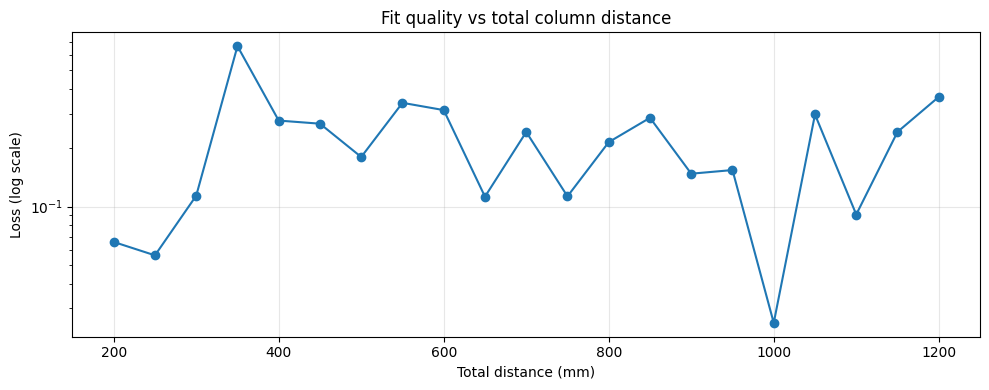


Best total distance: 1000 mm (loss = 2.528852e-02)


In [12]:
# ================================================================
# REAL DATA INVERSION — MODE C (30k-600k)
# ================================================================
# Constraints:
#   1. |A| ratios match labeled magnification ratios (13 equations)
#   2. B = 0 at every setting (image in focus) (14 equations)
#   Total: 27 equations for 8 unknowns
#
# OLf and PL1 are both constant in Mode C.

mask_c = dac["mode"] == "C"
dac_c = {k: dac[k][mask_c] for k in dac}
n_c = int(mask_c.sum())

DAC_C = np.column_stack([dac_c[ln] for ln in LENS_NAMES])
MAG_C = dac_c["mag"]

print(f"Mode C: {n_c} settings, mag range {MAG_C[0]:.0f}x - {MAG_C[-1]:.0f}x")
print(f"Constraints: {n_c-1} mag ratios + {n_c} B=0 = {2*n_c-1} equations")
print(f"Unknowns: {n_dist_fit} distances + {N_LENSES} Cf = {n_dist_fit + N_LENSES}")

# ---- Scan total distances ----
TOTAL_DIST_CANDIDATES = np.arange(0.2, 1.25, 0.05)

print(f"\n--- Scanning {len(TOTAL_DIST_CANDIDATES)} total distances ---")
results_by_Dtot = {}

for D_tot in TOTAL_DIST_CANDIDATES:
    n_df = N_DISTS - 1
    n_p = n_df + N_LENSES
    
    rfn = make_dac_residual_fn(
        DAC_C, MAG_C,
        n_lenses=N_LENSES, n_dists=N_DISTS,
        total_distance=D_tot,
        use_mag_ratios=True, use_B_zero=True,
        B_weight=1.0,
    )
    
    lo = np.concatenate([np.full(n_df, 2e-3), np.full(N_LENSES, 1e-14)])
    hi = np.concatenate([np.full(n_df, D_tot * 0.8), np.full(N_LENSES, 1e-6)])
    
    # Multi-start
    rng_scan = np.random.default_rng(123)
    best_x_scan = None
    best_loss_scan = np.inf
    
    for s in range(40):
        d_init = rng_scan.uniform(5e-3, D_tot * 0.3, n_df)
        d_init = d_init / d_init.sum() * D_tot * 0.7
        cf_init = 10**rng_scan.uniform(-12, -8, N_LENSES)
        x0_s = np.concatenate([d_init, cf_init])
        x0_s = np.clip(x0_s, lo + 1e-15, hi - 1e-15)
        
        try:
            sol = least_squares(rfn, x0_s, bounds=(lo, hi), method="trf",
                                ftol=1e-10, xtol=1e-10, gtol=1e-10, max_nfev=10000)
            loss = np.sum(rfn(sol.x)**2)
            if loss < best_loss_scan:
                best_loss_scan = loss
                best_x_scan = sol.x.copy()
        except:
            pass
    
    # Refine
    if best_x_scan is not None:
        for _ in range(5):
            try:
                sol = least_squares(rfn, best_x_scan, bounds=(lo, hi), method="trf",
                                    ftol=1e-13, xtol=1e-13, gtol=1e-13, max_nfev=20000)
                loss = np.sum(rfn(sol.x)**2)
                if loss < best_loss_scan:
                    best_loss_scan = loss
                    best_x_scan = sol.x.copy()
            except:
                pass
    
    results_by_Dtot[D_tot] = (best_x_scan, best_loss_scan)
    print(f"  D_tot={D_tot*1e3:>6.0f}mm: loss={best_loss_scan:.4e}")

# Plot loss vs D_tot
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
Ds = np.array(sorted(results_by_Dtot.keys()))
Ls = np.array([results_by_Dtot[d][1] for d in Ds])
ax.semilogy(Ds * 1e3, Ls, "o-", markersize=6)
ax.set_xlabel("Total distance (mm)")
ax.set_ylabel("Loss (log scale)")
ax.set_title("Fit quality vs total column distance")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Pick best
best_Dtot = Ds[np.argmin(Ls)]
best_x_real, best_loss_real = results_by_Dtot[best_Dtot]
print(f"\nBest total distance: {best_Dtot*1e3:.0f} mm (loss = {best_loss_real:.6e})")

In [13]:
# ================================================================
# REFINE BEST SOLUTION & ANALYZE RESULTS
# ================================================================

D_tot = best_Dtot
n_df = N_DISTS - 1

# Refine with more starts and tighter convergence
rfn_ref = make_dac_residual_fn(
    DAC_C, MAG_C,
    n_lenses=N_LENSES, n_dists=N_DISTS,
    total_distance=D_tot,
    use_mag_ratios=True, use_B_zero=True,
    B_weight=1.0,
)

lo_ref = np.concatenate([np.full(n_df, 2e-3), np.full(N_LENSES, 1e-14)])
hi_ref = np.concatenate([np.full(n_df, D_tot * 0.8), np.full(N_LENSES, 1e-6)])

print("Refined optimization (200 starts, B=0 enforced)...")
best_x_ref, best_loss_ref = solve_dac_least_squares(
    rfn_ref, best_x_real, bounds=(lo_ref, hi_ref),
    n_starts=200, refine=30, seed=42, verbose=True,
)

print(f"\nFinal loss: {best_loss_ref:.6e}")

# Extract parameters
d_fit_ref = best_x_ref[:n_df]
d_last_ref = D_tot - np.sum(d_fit_ref)
d_all_ref = np.concatenate([d_fit_ref, [d_last_ref]])
Cf_fit_ref = best_x_ref[n_df:]

print(f"\n{'='*60}")
print(f"RECOVERED COLUMN PARAMETERS (Mode C, D_tot = {D_tot*1e3:.0f} mm)")
print(f"{'='*60}")

labels_d = ["OL_img -> IL1", "IL1 -> IL2", "IL2 -> IL3", "IL3 -> PL1", "PL1 -> detector"]
print(f"\nDistances (mm):")
for i in range(N_DISTS):
    print(f"  d[{i}] ({labels_d[i]:>16s}) = {d_all_ref[i]*1e3:>8.2f} mm")
print(f"  Total = {np.sum(d_all_ref)*1e3:.2f} mm")

print(f"\nFocal length coefficients Cf_tilde:")
for i, name in enumerate(LENS_NAMES):
    print(f"  Cf_tilde[{name}] = {Cf_fit_ref[i]:.6e}")

# Compute focal lengths at each Mode C setting
print(f"\nFocal lengths at each setting (mm):")
print(f"  {'Mag':>8s}", end="")
for name in LENS_NAMES:
    print(f"  {f'f_{name}':>10s}", end="")
print()

for i in range(n_c):
    dac_row = DAC_C[i]
    focals = 1.0 / (Cf_fit_ref * dac_row**2)
    print(f"  {MAG_C[i]:>8.0f}", end="")
    for j in range(N_LENSES):
        print(f"  {focals[j]*1e3:>10.3f}", end="")
    print()

# Compute predicted magnifications and B values
print(f"\nMagnification & focus comparison:")
print(f"  {'Mag_label':>10s} {'A_pred':>12s} {'|A|_pred':>10s} "
      f"{'Ratio_pred':>12s} {'Ratio_label':>12s} {'Rel_err%':>8s} {'B_pred':>10s}")

A_preds = []
B_preds = []
for i in range(n_c):
    dac_row = jnp.array(DAC_C[i])
    d_j = jnp.array(d_all_ref)
    cf_j = jnp.array(Cf_fit_ref)
    A_val = float(predicted_magnification(d_j, cf_j, dac_row))
    B_val = float(predicted_B(d_j, cf_j, dac_row))
    A_preds.append(A_val)
    B_preds.append(B_val)

A_preds = np.array(A_preds)
B_preds = np.array(B_preds)
ratio_pred = np.abs(A_preds) / np.abs(A_preds[0])
ratio_label = MAG_C / MAG_C[0]

for i in range(n_c):
    err = 100 * abs(ratio_pred[i] - ratio_label[i]) / ratio_label[i]
    print(f"  {MAG_C[i]:>10.0f} {A_preds[i]:>12.2f} {abs(A_preds[i]):>10.2f} "
          f"{ratio_pred[i]:>12.4f} {ratio_label[i]:>12.4f} {err:>8.3f} {B_preds[i]:>10.6f}")

print(f"\nMax mag-ratio error: {np.max(100*np.abs(ratio_pred-ratio_label)/ratio_label):.3f}%")
print(f"RMS mag-ratio error: {np.sqrt(np.mean((100*(ratio_pred-ratio_label)/ratio_label)**2)):.3f}%")
print(f"Max |B|: {np.max(np.abs(B_preds)):.6e} m")
print(f"Mean |B|: {np.mean(np.abs(B_preds)):.6e} m")

Refined optimization (200 starts, B=0 enforced)...
  start 40/200: best loss = 2.635e-02
  start 80/200: best loss = 2.272e-02
  start 120/200: best loss = 2.272e-02
  start 160/200: best loss = 2.113e-02
  start 200/200: best loss = 2.113e-02

Final loss: 2.112833e-02

RECOVERED COLUMN PARAMETERS (Mode C, D_tot = 1000 mm)

Distances (mm):
  d[0] (   OL_img -> IL1) =    39.63 mm
  d[1] (      IL1 -> IL2) =   124.85 mm
  d[2] (      IL2 -> IL3) =   111.20 mm
  d[3] (      IL3 -> PL1) =   463.43 mm
  d[4] ( PL1 -> detector) =   260.89 mm
  Total = 1000.00 mm

Focal length coefficients Cf_tilde:
  Cf_tilde[IL1] = 1.903036e-08
  Cf_tilde[IL2] = 4.101016e-08
  Cf_tilde[IL3] = 1.085222e-08
  Cf_tilde[PL1] = 1.735620e-09

Focal lengths at each setting (mm):
       Mag       f_IL1       f_IL2       f_IL3       f_PL1
     30000      31.663      39.449      58.369     140.665
     40000      30.101      39.449      72.937     140.665
     50000      28.939      36.769      78.640     140.665
   

## Stage 4: Cross-Mode Inversion (Modes B+C)

Mode B adds PL1 variation — since PL1 is at a different DAC value at each setting,
the $\tilde{C}_{f,\text{PL1}}$ parameter gets additional constraints.

The same physical column (same distances, same $\tilde{C}_f$) applies in both modes.
The only difference is that OLf is constant (39178) in both B and C, while PL1
varies in Mode B.

Adding Mode B data (6 more settings) with the same 8 unknowns substantially
overdetermines the system.

In [14]:
# ================================================================
# DIAGNOSTIC: B-ONLY FIT, THEN B + MAG RATIOS, THEN CROSS-MODE
# ================================================================
# Step 1: Fit B=0 ONLY (exact constraint, no magnification info)
# Step 2: Add magnification ratios with B_weight sweep
# Step 3: Cross-mode B+C inversion

# ---- Step 1: B=0 only (Mode C) ----
# Try several B_weights with make_dac_residual_fn
# Actually, let's make a pure B=0 residual by using B_weight=1 and no mag ratios
print("="*60)
print("STEP 1: B=0 only (Mode C, 14 equations, 8 unknowns)")
print("="*60)

# Scan D_tot with B=0 only
B_only_results = {}
for D_tot_test in [0.25, 0.35, 0.50, 0.70, 1.00]:
    n_df = N_DISTS - 1
    rfn_B = make_dac_residual_fn(
        DAC_C, MAG_C,
        n_lenses=N_LENSES, n_dists=N_DISTS,
        total_distance=D_tot_test,
        use_mag_ratios=False,  # NO magnification info
        use_B_zero=True,
        B_weight=1.0,
    )
    
    lo_B = np.concatenate([np.full(n_df, 2e-3), np.full(N_LENSES, 1e-14)])
    hi_B = np.concatenate([np.full(n_df, D_tot_test * 0.8), np.full(N_LENSES, 1e-6)])
    
    rng_B = np.random.default_rng(777)
    best_x_B = None
    best_loss_B = np.inf
    
    for s_B in range(100):
        d_init = rng_B.uniform(5e-3, D_tot_test * 0.3, n_df)
        d_init = d_init / d_init.sum() * D_tot_test * 0.7
        cf_init = 10**rng_B.uniform(-12, -7, N_LENSES)
        x0_B = np.concatenate([d_init, cf_init])
        x0_B = np.clip(x0_B, lo_B + 1e-15, hi_B - 1e-15)
        
        try:
            sol = least_squares(rfn_B, x0_B, bounds=(lo_B, hi_B), method="trf",
                                ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=10000)
            loss = np.sum(rfn_B(sol.x)**2)
            if loss < best_loss_B:
                best_loss_B = loss
                best_x_B = sol.x.copy()
        except:
            pass
    
    # Refine
    if best_x_B is not None:
        for _ in range(10):
            try:
                sol = least_squares(rfn_B, best_x_B, bounds=(lo_B, hi_B), method="trf",
                                    ftol=1e-14, xtol=1e-14, gtol=1e-14, max_nfev=20000)
                loss = np.sum(rfn_B(sol.x)**2)
                if loss < best_loss_B:
                    best_loss_B = loss
                    best_x_B = sol.x.copy()
            except:
                pass
    
    B_only_results[D_tot_test] = (best_x_B, best_loss_B)
    
    # Report
    d_bonly = np.concatenate([best_x_B[:n_df], [D_tot_test - np.sum(best_x_B[:n_df])]])
    cf_bonly = best_x_B[n_df:]
    
    # Compute B values at this solution
    B_vals_check = []
    A_vals_check = []
    for i in range(n_c):
        dac_row = jnp.array(DAC_C[i])
        A_v = float(predicted_magnification(jnp.array(d_bonly), jnp.array(cf_bonly), dac_row))
        B_v = float(predicted_B(jnp.array(d_bonly), jnp.array(cf_bonly), dac_row))
        A_vals_check.append(A_v)
        B_vals_check.append(B_v)
    
    A_vals_check = np.array(A_vals_check)
    B_vals_check = np.array(B_vals_check)
    ratio_check = np.abs(A_vals_check) / np.abs(A_vals_check[0])
    ratio_label_check = MAG_C / MAG_C[0]
    ratio_err = 100 * np.abs(ratio_check - ratio_label_check) / ratio_label_check
    
    print(f"\n  D_tot={D_tot_test*1e3:.0f}mm: B_loss={best_loss_B:.4e}, "
          f"max|B|={np.max(np.abs(B_vals_check))*1e3:.3f}mm, "
          f"mag_ratio_err: max={np.max(ratio_err):.1f}%, rms={np.sqrt(np.mean(ratio_err**2)):.1f}%")
    print(f"    d (mm): {[f'{x*1e3:.1f}' for x in d_bonly]}")
    print(f"    Cf:     {[f'{x:.3e}' for x in cf_bonly]}")
    print(f"    |A| range: {np.abs(A_vals_check[0]):.1f} to {np.abs(A_vals_check[-1]):.1f}")

# ---- Step 2: Sweep B_weight with B+mag (Mode C) ----
print(f"\n{'='*60}")
print("STEP 2: B_weight sweep (B=0 + mag ratios, Mode C)")
print("="*60)

D_tot_ref = best_Dtot  # From the scan in cell 13

for bw in [1, 5, 10, 20, 50]:
    rfn_bw = make_dac_residual_fn(
        DAC_C, MAG_C,
        n_lenses=N_LENSES, n_dists=N_DISTS,
        total_distance=D_tot_ref,
        use_mag_ratios=True, use_B_zero=True,
        B_weight=bw,
    )
    
    lo_bw = np.concatenate([np.full(n_df, 2e-3), np.full(N_LENSES, 1e-14)])
    hi_bw = np.concatenate([np.full(n_df, D_tot_ref * 0.8), np.full(N_LENSES, 1e-6)])
    
    rng_bw = np.random.default_rng(999)
    best_x_bw = None
    best_loss_bw = np.inf
    
    for s_bw in range(80):
        d_init = rng_bw.uniform(5e-3, D_tot_ref * 0.3, n_df)
        d_init = d_init / d_init.sum() * D_tot_ref * 0.7
        cf_init = 10**rng_bw.uniform(-12, -7, N_LENSES)
        x0_bw = np.concatenate([d_init, cf_init])
        x0_bw = np.clip(x0_bw, lo_bw + 1e-15, hi_bw - 1e-15)
        
        try:
            sol = least_squares(rfn_bw, x0_bw, bounds=(lo_bw, hi_bw), method="trf",
                                ftol=1e-12, xtol=1e-12, gtol=1e-12, max_nfev=10000)
            loss = np.sum(rfn_bw(sol.x)**2)
            if loss < best_loss_bw:
                best_loss_bw = loss
                best_x_bw = sol.x.copy()
        except:
            pass
    
    # Refine
    for _ in range(10):
        try:
            sol = least_squares(rfn_bw, best_x_bw, bounds=(lo_bw, hi_bw), method="trf",
                                ftol=1e-14, xtol=1e-14, gtol=1e-14, max_nfev=20000)
            loss = np.sum(rfn_bw(sol.x)**2)
            if loss < best_loss_bw:
                best_loss_bw = loss
                best_x_bw = sol.x.copy()
        except:
            pass
    
    d_bw = np.concatenate([best_x_bw[:n_df], [D_tot_ref - np.sum(best_x_bw[:n_df])]])
    cf_bw = best_x_bw[n_df:]
    
    B_vals_bw = []
    A_vals_bw = []
    for i in range(n_c):
        dac_row = jnp.array(DAC_C[i])
        A_v = float(predicted_magnification(jnp.array(d_bw), jnp.array(cf_bw), dac_row))
        B_v = float(predicted_B(jnp.array(d_bw), jnp.array(cf_bw), dac_row))
        A_vals_bw.append(A_v)
        B_vals_bw.append(B_v)
    
    A_vals_bw = np.array(A_vals_bw)
    B_vals_bw = np.array(B_vals_bw)
    ratio_bw = np.abs(A_vals_bw) / np.abs(A_vals_bw[0])
    ratio_err_bw = 100 * np.abs(ratio_bw - ratio_label) / ratio_label
    
    print(f"\n  B_weight={bw:>3d}: loss={best_loss_bw:.4e}, "
          f"max|B|={np.max(np.abs(B_vals_bw))*1e3:.3f}mm, "
          f"mag_err: max={np.max(ratio_err_bw):.1f}%, rms={np.sqrt(np.mean(ratio_err_bw**2)):.1f}%")
    print(f"    d (mm): {[f'{x*1e3:.1f}' for x in d_bw]}")
    print(f"    Cf:     {[f'{x:.3e}' for x in cf_bw]}")

# ---- Step 3: Cross-mode B+C ----
print(f"\n{'='*60}")
print("STEP 3: Cross-mode B+C (PL1 varies in Mode B)")
print("="*60)

mask_bc = np.isin(dac["mode"], ["B", "C"])
dac_bc = {k: dac[k][mask_bc] for k in dac}
n_bc = int(mask_bc.sum())

DAC_BC = np.column_stack([dac_bc[ln] for ln in LENS_NAMES])
MAG_BC = dac_bc["mag"]

print(f"Modes B+C: {n_bc} settings, mag range {MAG_BC[0]:.0f}x - {MAG_BC[-1]:.0f}x")

rfn_bc = make_dac_residual_fn(
    DAC_BC, MAG_BC,
    n_lenses=N_LENSES, n_dists=N_DISTS,
    total_distance=D_tot_ref,
    use_mag_ratios=True, use_B_zero=True,
    B_weight=10.0,  # Strong B=0 enforcement
)

lo_bc = np.concatenate([np.full(n_df, 2e-3), np.full(N_LENSES, 1e-14)])
hi_bc = np.concatenate([np.full(n_df, D_tot_ref * 0.8), np.full(N_LENSES, 1e-6)])

# Multi-start from diverse initial conditions
rng_bc = np.random.default_rng(42)
best_x_bc = None
best_loss_bc = np.inf

for s_bc in range(200):
    d_init = rng_bc.uniform(5e-3, D_tot_ref * 0.3, n_df)
    d_init = d_init / d_init.sum() * D_tot_ref * 0.7
    cf_init = 10**rng_bc.uniform(-12, -7, N_LENSES)
    x0_bc = np.concatenate([d_init, cf_init])
    x0_bc = np.clip(x0_bc, lo_bc + 1e-15, hi_bc - 1e-15)
    
    try:
        sol = least_squares(rfn_bc, x0_bc, bounds=(lo_bc, hi_bc), method="trf",
                            ftol=1e-11, xtol=1e-11, gtol=1e-11, max_nfev=10000)
        loss = np.sum(rfn_bc(sol.x)**2)
        if loss < best_loss_bc:
            best_loss_bc = loss
            best_x_bc = sol.x.copy()
    except:
        pass
    
    if (s_bc + 1) % 50 == 0:
        print(f"  start {s_bc+1}/200: best loss = {best_loss_bc:.3e}")

# Refine
for _ in range(20):
    try:
        sol = least_squares(rfn_bc, best_x_bc, bounds=(lo_bc, hi_bc), method="trf",
                            ftol=1e-14, xtol=1e-14, gtol=1e-14, max_nfev=30000)
        loss = np.sum(rfn_bc(sol.x)**2)
        if loss < best_loss_bc:
            best_loss_bc = loss
            best_x_bc = sol.x.copy()
    except:
        pass

d_bc = np.concatenate([best_x_bc[:n_df], [D_tot_ref - np.sum(best_x_bc[:n_df])]])
cf_bc = best_x_bc[n_df:]

print(f"\nFinal B+C loss: {best_loss_bc:.6e}")
print(f"\nDistances (mm):")
labels_d = ["OL_img -> IL1", "IL1 -> IL2", "IL2 -> IL3", "IL3 -> PL1", "PL1 -> detector"]
for i in range(N_DISTS):
    print(f"  d[{i}] ({labels_d[i]:>16s}) = {d_bc[i]*1e3:>8.2f} mm")
print(f"  Total = {np.sum(d_bc)*1e3:.2f} mm")

print(f"\nCf_tilde:")
for i, name in enumerate(LENS_NAMES):
    print(f"  Cf_tilde[{name}] = {cf_bc[i]:.6e}")

# Predicted vs label for B+C
A_bc_all = []
B_bc_all = []
for i in range(n_bc):
    dac_row = jnp.array(DAC_BC[i])
    A_v = float(predicted_magnification(jnp.array(d_bc), jnp.array(cf_bc), dac_row))
    B_v = float(predicted_B(jnp.array(d_bc), jnp.array(cf_bc), dac_row))
    A_bc_all.append(A_v)
    B_bc_all.append(B_v)

A_bc_all = np.array(A_bc_all)
B_bc_all = np.array(B_bc_all)

print(f"\nMax |B|: {np.max(np.abs(B_bc_all))*1e3:.3f} mm")
print(f"Mean |B|: {np.mean(np.abs(B_bc_all))*1e3:.3f} mm")

ratio_bc_pred = np.abs(A_bc_all) / np.abs(A_bc_all[0])
ratio_bc_label = MAG_BC / MAG_BC[0]
ratio_err_bc = 100 * np.abs(ratio_bc_pred - ratio_bc_label) / ratio_bc_label
print(f"Max mag-ratio error: {np.max(ratio_err_bc):.2f}%")
print(f"RMS mag-ratio error: {np.sqrt(np.mean(ratio_err_bc**2)):.2f}%")

print(f"\nPer-setting comparison:")
print(f"  {'Mode':>5s} {'Mag':>8s} {'|A|':>8s} {'B(mm)':>8s} "
      f"{'ratio_p':>8s} {'ratio_l':>8s} {'err%':>6s}")
modes_bc = dac_bc["mode"]
for i in range(n_bc):
    err = ratio_err_bc[i]
    print(f"  {modes_bc[i]:>5s} {MAG_BC[i]:>8.0f} {abs(A_bc_all[i]):>8.2f} "
          f"{B_bc_all[i]*1e3:>8.3f} {ratio_bc_pred[i]:>8.4f} "
          f"{ratio_bc_label[i]:>8.4f} {err:>6.2f}")

STEP 1: B=0 only (Mode C, 14 equations, 8 unknowns)

  D_tot=250mm: B_loss=1.2743e+01, max|B|=128.871mm, mag_ratio_err: max=60.5%, rms=50.3%
    d (mm): ['2.0', '25.0', '72.5', '200.0', '-49.5']
    Cf:     ['3.096e-07', '7.322e-08', '1.429e-08', '6.301e-07']
    |A| range: 5187.8 to 57046.9

  D_tot=350mm: B_loss=1.1745e+01, max|B|=230.683mm, mag_ratio_err: max=61.3%, rms=50.7%
    d (mm): ['2.0', '26.5', '84.7', '280.0', '-43.2']
    Cf:     ['3.082e-07', '6.690e-08', '1.172e-08', '1.000e-06']
    |A| range: 9232.5 to 101746.4

  D_tot=500mm: B_loss=1.0300e+01, max|B|=385.751mm, mag_ratio_err: max=65.3%, rms=52.9%
    d (mm): ['2.0', '31.9', '120.8', '400.0', '-54.7']
    Cf:     ['3.040e-07', '5.167e-08', '8.331e-09', '1.000e-06']
    |A| range: 15048.6 to 166842.8

  D_tot=700mm: B_loss=8.7450e+00, max|B|=579.319mm, mag_ratio_err: max=68.5%, rms=54.5%
    d (mm): ['2.0', '36.9', '163.4', '560.0', '-62.2']
    Cf:     ['3.012e-07', '4.229e-08', '6.190e-09', '1.000e-06']
    |A| rang

In [ ]:
# ================================================================
# IMPROVED PARAMETERIZATION: Softmax distances + log Cf
# ================================================================
# Fix the d[4] < 0 bug by using softmax parameterization.
# Parameter vector: [alpha_0, ..., alpha_4, log10(Cf_0), ..., log10(Cf_3)]
# Distances: d_i = D_tot * softmax(alpha)[i]  (guarantees d_i > 0, sum = D_tot)
# Cf: Cf_i = 10^(log10_Cf_i)
#
# This is UNCONSTRAINED, so we can use scipy.optimize.minimize with L-BFGS-B.

from scipy.optimize import minimize, differential_evolution

def make_residual_softmax(dac_matrix, target_mags, n_lenses, total_distance,
                          use_mag_ratios=True, use_B_zero=True, B_weight=1.0):
    """Residual function with softmax+log parameterization."""
    dac_j = jnp.array(dac_matrix)
    target_j = jnp.array(target_mags)
    n_settings = dac_matrix.shape[0]
    n_dists = n_lenses + 1  # One more distance than lenses
    
    if use_mag_ratios:
        log_target_ratios = jnp.log(jnp.abs(target_j) / jnp.abs(target_j[0]))
    
    @jax.jit
    def rfn_jit(params):
        # Unpack: first n_dists are alpha (softmax weights), next n_lenses are log10(Cf)
        alphas = params[:n_dists]
        log_Cf = params[n_dists:n_dists + n_lenses]
        
        # Softmax for distances: all positive and sum to D_tot
        exp_a = jnp.exp(alphas - jnp.max(alphas))  # numerical stability
        dists = total_distance * exp_a / jnp.sum(exp_a)
        
        # Cf from log scale
        Cf = 10.0**log_Cf
        
        def compute_one(dac_row):
            focals = focals_from_dac(Cf, dac_row)
            M = build_abcd(dists, focals, xp=jnp)
            return M[0, 0], M[0, 1]
        
        A_pred, B_pred = jax.vmap(compute_one)(dac_j)
        
        residuals = []
        
        if use_mag_ratios:
            log_pred_ratios = jnp.log(jnp.abs(A_pred) / jnp.abs(A_pred[0]))
            residuals.append(log_pred_ratios[1:] - log_target_ratios[1:])
        
        if use_B_zero:
            residuals.append(B_weight * B_pred / total_distance)
        
        return jnp.concatenate(residuals)
    
    @jax.jit
    def loss_jit(params):
        res = rfn_jit(params)
        return jnp.sum(res**2)
    
    grad_fn = jax.jit(jax.grad(loss_jit))
    
    def loss_np(x):
        return float(loss_jit(jnp.array(x)))
    
    def grad_np(x):
        return np.asarray(grad_fn(jnp.array(x)))
    
    def rfn_np(x):
        return np.asarray(rfn_jit(jnp.array(x)))
    
    return rfn_np, loss_np, grad_np


def decode_softmax_params(params, n_dists, n_lenses, total_distance):
    """Decode softmax+log params into physical distances and Cf."""
    alphas = params[:n_dists]
    log_Cf = params[n_dists:n_dists + n_lenses]
    
    exp_a = np.exp(alphas - np.max(alphas))
    dists = total_distance * exp_a / np.sum(exp_a)
    Cf = 10.0**log_Cf
    
    return dists, Cf


# ---- Multi-start L-BFGS-B optimization ----
def solve_softmax(dac_matrix, target_mags, n_lenses, total_distance,
                  use_mag_ratios=True, use_B_zero=True, B_weight=1.0,
                  n_starts=200, seed=42):
    """Multi-start optimization with softmax parameterization."""
    n_dists = n_lenses + 1
    n_p = n_dists + n_lenses
    
    rfn, loss_fn, grad_fn = make_residual_softmax(
        dac_matrix, target_mags, n_lenses, total_distance,
        use_mag_ratios=use_mag_ratios, use_B_zero=use_B_zero, B_weight=B_weight,
    )
    
    rng = np.random.default_rng(seed)
    best_x = None
    best_loss = np.inf
    solutions = []
    
    for s in range(n_starts):
        # Random initial: alphas ~ U(-2, 2), log_Cf ~ U(-11, -7)
        alpha_init = rng.uniform(-2, 2, n_dists)
        logcf_init = rng.uniform(-11, -7, n_lenses)
        x0 = np.concatenate([alpha_init, logcf_init])
        
        try:
            sol = minimize(loss_fn, x0, jac=grad_fn, method="L-BFGS-B",
                          options={"maxiter": 5000, "ftol": 1e-8, "gtol": 1e-8})
            loss = sol.fun
            if loss < best_loss:
                best_loss = loss
                best_x = sol.x.copy()
            if loss < 1.0:  # Collect reasonable solutions
                solutions.append((sol.x.copy(), loss))
        except:
            pass
        
        if (s + 1) % 50 == 0:
            print(f"  start {s+1}/{n_starts}: best loss = {best_loss:.4e}, "
                  f"collected {len(solutions)} solutions")
    
    # Refine best
    for _ in range(20):
        try:
            sol = minimize(loss_fn, best_x, jac=grad_fn, method="L-BFGS-B",
                          options={"maxiter": 10000, "ftol": 1e-8, "gtol": 1e-8})
            if sol.fun < best_loss:
                best_loss = sol.fun
                best_x = sol.x.copy()
        except:
            pass
    
    return best_x, best_loss, solutions


# ================================================================
# TEST 1: B=0 only, scan D_tot (proper parameterization)
# ================================================================
print("="*60)
print("B=0 ONLY (softmax parameterization)")
print("="*60)

for D_tot_test in [0.25, 0.35, 0.50, 0.75, 1.00]:
    print(f"\n  D_tot = {D_tot_test*1e3:.0f} mm:")
    
    best_x_s, best_loss_s, sols_s = solve_softmax(
        DAC_C, MAG_C, N_LENSES, D_tot_test,
        use_mag_ratios=False, use_B_zero=True, B_weight=1.0,
        n_starts=100, seed=777
    )
    
    dists_s, Cf_s = decode_softmax_params(best_x_s, N_DISTS, N_LENSES, D_tot_test)
    
    # Compute B and A at this solution
    B_vals_s = []
    A_vals_s = []
    for i in range(n_c):
        dac_row = jnp.array(DAC_C[i])
        A_v = float(predicted_magnification(jnp.array(dists_s), jnp.array(Cf_s), dac_row))
        B_v = float(predicted_B(jnp.array(dists_s), jnp.array(Cf_s), dac_row))
        A_vals_s.append(A_v)
        B_vals_s.append(B_v)
    
    A_vals_s = np.array(A_vals_s)
    B_vals_s = np.array(B_vals_s)
    
    ratio_s = np.abs(A_vals_s) / np.abs(A_vals_s[0])
    ratio_lab = MAG_C / MAG_C[0]
    ratio_err_s = 100 * np.abs(ratio_s - ratio_lab) / ratio_lab
    
    print(f"    B_loss={best_loss_s:.4e}, max|B|={np.max(np.abs(B_vals_s))*1e6:.1f}μm")
    print(f"    d (mm): {[f'{x*1e3:.2f}' for x in dists_s]}")
    print(f"    Cf:     {[f'{x:.3e}' for x in Cf_s]}")
    print(f"    |A| range: {np.abs(A_vals_s[0]):.2f} to {np.abs(A_vals_s[-1]):.2f}")
    print(f"    Mag-ratio err: max={np.max(ratio_err_s):.1f}%, rms={np.sqrt(np.mean(ratio_err_s**2)):.1f}%")
    print(f"    # solutions with loss < 1: {len(sols_s)}")

# ================================================================
# TEST 2: B=0 + mag ratios, scan D_tot + B_weight
# ================================================================
print(f"\n{'='*60}")
print("B=0 + MAG RATIOS (softmax parameterization)")
print("="*60)

for D_tot_test in [0.25, 0.50, 0.75, 1.00]:
    for bw in [1, 10, 50]:
        best_x_s2, best_loss_s2, sols_s2 = solve_softmax(
            DAC_C, MAG_C, N_LENSES, D_tot_test,
            use_mag_ratios=True, use_B_zero=True, B_weight=bw,
            n_starts=100, seed=42
        )
        
        dists_s2, Cf_s2 = decode_softmax_params(best_x_s2, N_DISTS, N_LENSES, D_tot_test)
        
        B_vals_s2 = []
        A_vals_s2 = []
        for i in range(n_c):
            dac_row = jnp.array(DAC_C[i])
            A_v = float(predicted_magnification(jnp.array(dists_s2), jnp.array(Cf_s2), dac_row))
            B_v = float(predicted_B(jnp.array(dists_s2), jnp.array(Cf_s2), dac_row))
            A_vals_s2.append(A_v)
            B_vals_s2.append(B_v)
        
        A_vals_s2 = np.array(A_vals_s2)
        B_vals_s2 = np.array(B_vals_s2)
        
        ratio_s2 = np.abs(A_vals_s2) / np.abs(A_vals_s2[0])
        ratio_err_s2 = 100 * np.abs(ratio_s2 - ratio_lab) / ratio_lab
        
        print(f"\n  D={D_tot_test*1e3:.0f}mm, Bw={bw:>3d}: loss={best_loss_s2:.4e}, "
              f"max|B|={np.max(np.abs(B_vals_s2))*1e3:.2f}mm, "
              f"mag_err: max={np.max(ratio_err_s2):.1f}%, "
              f"rms={np.sqrt(np.mean(ratio_err_s2**2)):.1f}%")
        print(f"    d(mm): {[f'{x*1e3:.1f}' for x in dists_s2]}")
        print(f"    f_range(mm): IL2 {1e3/(Cf_s2[1]*DAC_C[0,1]**2):.1f}-{1e3/(Cf_s2[1]*DAC_C[-1,1]**2):.1f}, "
              f"IL3 {1e3/(Cf_s2[2]*DAC_C[0,2]**2):.1f}-{1e3/(Cf_s2[2]*DAC_C[-1,2]**2):.1f}")

B=0 ONLY (softmax parameterization)

  D_tot = 250 mm:
  start 50/100: best loss = 1.9769e-13, collected 50 solutions
  start 100/100: best loss = 1.2102e-13, collected 99 solutions
    B_loss=1.1403e-13, max|B|=0.0μm
    d (mm): ['0.00', '63.07', '0.00', '0.00', '186.93']
    Cf:     ['1.158e+12', '4.159e-14', '1.412e-13', '5.177e-09']
    |A| range: 2169897575010536.00 to 824682850323928.88
    Mag-ratio err: max=99.7%, rms=88.6%
    # solutions with loss < 1: 99

  D_tot = 350 mm:
  start 50/100: best loss = 7.7864e-15, collected 50 solutions
  start 100/100: best loss = 7.7864e-15, collected 99 solutions
    B_loss=7.7234e-15, max|B|=0.0μm
    d (mm): ['0.00', '350.00', '0.00', '0.00', '0.00']
    Cf:     ['5.659e+82', '3.015e-02', '1.946e-03', '6.285e+03']
    |A| range: 10918930468728123101617969652800240368466171599712876712951551428290490747476416397312.00 to 62569362706576913548979568173682937604495106611032395460156051409875253282969162350592.00
    Mag-ratio err: max=92.7%, 

## Constrained MAP Inversion (restart-safe)

This section uses a physically constrained parameterization and priors:

- Distances are strictly positive
- Constraint: $d_{\mathrm{IL1\to IL2}} = d_{\mathrm{IL3\to PL1}}$
- PL1 focal length at DAC=64000 is constrained to 1-5 mm
- Objective lens is included as a multiplicative block with:
  - $f_{\mathrm{OL}}$ prior centered at 2.3 mm
  - objective magnification constrained to 20x-200x

We fit Mode B+C first (where OLf is constant), using both:
- magnification ratios (robust to nominal scale error)
- soft absolute-magnification term (to anchor objective contribution)
- focus condition $B \approx 0$.

In [ ]:
# ================================================================
# CONSTRAINED MAP INVERSION (Mode B+C, restart-safe)
# ================================================================
from scipy.optimize import minimize

# ---------- data ----------
mask_bc = np.isin(dac["mode"], ["B", "C"])
dac_bc = {k: dac[k][mask_bc] for k in dac}
DAC_BC = np.column_stack([dac_bc[ln] for ln in ["IL1", "IL2", "IL3", "PL1"]])
MAG_BC = dac_bc["mag"].astype(float)
n_bc = len(MAG_BC)

print(f"Mode B+C points: {n_bc}, mag range: {MAG_BC[0]:.0f}x to {MAG_BC[-1]:.0f}x")

# ---------- helpers ----------
def softplus(x):
    return np.log1p(np.exp(-np.abs(x))) + np.maximum(x, 0.0)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def decode_params_constrained(theta):
    """
    theta layout:
      [u0,u1,u2,u3, logCf1,logCf2,logCf3, u_pl1, u_fol, u_Lobj]

    distances:
      d0 = softplus(u0)+eps
      d1 = softplus(u1)+eps
      d2 = softplus(u2)+eps
      d3 = d1   (hard equality constraint)
      d4 = softplus(u3)+eps

    Cf:
      IL1..IL3 from log10
      PL1 from bounded focal range at DAC=64000: f in [1,5] mm

    objective:
      f_OL in [1.5, 3.5] mm
      L_obj in [50, 500] mm
      M_OL = L_obj / f_OL, then softly constrained to [20,200]
    """
    eps_d = 1e-6

    d0 = softplus(theta[0]) + eps_d
    d1 = softplus(theta[1]) + eps_d
    d2 = softplus(theta[2]) + eps_d
    d3 = d1
    d4 = softplus(theta[3]) + eps_d
    dists = np.array([d0, d1, d2, d3, d4], dtype=float)

    # IL1..IL3
    cf_123 = 10.0 ** theta[4:7]

    # PL1 via bounded focal range at DAC=64000
    dac_pl1_ref = 64000.0
    f_pl1_min = 1e-3   # 1 mm
    f_pl1_max = 5e-3   # 5 mm
    cf_pl1_min = 1.0 / (f_pl1_max * dac_pl1_ref**2)
    cf_pl1_max = 1.0 / (f_pl1_min * dac_pl1_ref**2)
    cf_pl1 = cf_pl1_min + (cf_pl1_max - cf_pl1_min) * sigmoid(theta[7])

    Cf = np.concatenate([cf_123, [cf_pl1]])

    # Objective parameters
    f_ol_mm = 1.5 + 2.0 * sigmoid(theta[8])      # [1.5, 3.5] mm
    L_obj_mm = 50.0 + 450.0 * sigmoid(theta[9])  # [50, 500] mm
    M_ol = L_obj_mm / f_ol_mm

    aux = {
        "f_ol_mm": f_ol_mm,
        "L_obj_mm": L_obj_mm,
        "M_ol": M_ol,
        "cf_pl1_bounds": (cf_pl1_min, cf_pl1_max),
    }
    return dists, Cf, aux


def predict_A_B_with_obj(theta, dac_matrix):
    dists, Cf, aux = decode_params_constrained(theta)
    A_vals = []
    B_vals = []
    for i in range(dac_matrix.shape[0]):
        dac_row = dac_matrix[i]
        A_post = float(predicted_magnification(jnp.array(dists), jnp.array(Cf), jnp.array(dac_row)))
        B_post = float(predicted_B(jnp.array(dists), jnp.array(Cf), jnp.array(dac_row)))
        A_tot = aux["M_ol"] * A_post
        A_vals.append(A_tot)
        B_vals.append(B_post)
    return np.array(A_vals), np.array(B_vals), dists, Cf, aux


# ---------- objective (MAP-style) ----------
def objective_constrained(theta, w_ratio=1.0, w_B=40.0, w_abs=0.15, w_prior=1.0):
    A_tot, B_vals, dists, Cf, aux = predict_A_B_with_obj(theta, DAC_BC)

    # 1) magnification ratios
    ratio_pred = np.abs(A_tot) / (np.abs(A_tot[0]) + 1e-30)
    ratio_lab = MAG_BC / MAG_BC[0]
    r_ratio = np.log(ratio_pred + 1e-30) - np.log(ratio_lab + 1e-30)

    # 2) B≈0 focus condition (scaled by characteristic length)
    L_scale = np.sum(dists)
    r_B = B_vals / (L_scale + 1e-30)

    # 3) weak absolute-magnification anchor (labels are nominal)
    # allow ~10% typical error with low weight
    r_abs = np.log(np.abs(A_tot) + 1e-30) - np.log(MAG_BC + 1e-30)

    # 4) priors: f_OL ~ 2.3 mm, M_OL in [20,200] softly, and moderate total length
    r_fol = (aux["f_ol_mm"] - 2.3) / 0.4
    # soft hinge penalties for M_OL bounds
    low_violation = max(0.0, (20.0 - aux["M_ol"]) / 20.0)
    high_violation = max(0.0, (aux["M_ol"] - 200.0) / 200.0)
    r_mol = low_violation + high_violation
    r_len = (np.sum(dists) - 0.6) / 0.25

    loss = (
        w_ratio * np.mean(r_ratio**2)
        + w_B * np.mean(r_B**2)
        + w_abs * np.mean(r_abs**2)
        + w_prior * (r_fol**2 + 4.0 * r_mol**2 + 0.2 * r_len**2)
    )
    return float(loss)


# ---------- multistart solve ----------
def solve_constrained_map(n_starts=40, seed=7):
    rng = np.random.default_rng(seed)
    best = {"x": None, "loss": np.inf}

    for s in range(n_starts):
        # Initialization:
        # u-dist around 50-150mm scales
        u_dist = rng.normal(loc=np.log(np.exp(0.08)-1), scale=0.8, size=4)
        # IL1-3 Cf around f~3-20mm at DAC~30k-50k -> log10 Cf ~ [-9,-7]
        logcf = rng.uniform(-9.5, -7.2, size=3)
        # PL1 bounded param and objective params
        u_pl1 = rng.normal(0.0, 1.0, size=1)
        u_fol = rng.normal(0.0, 1.0, size=1)
        u_lobj = rng.normal(0.0, 1.0, size=1)

        x0 = np.concatenate([u_dist, logcf, u_pl1, u_fol, u_lobj])

        try:
            sol = minimize(
                objective_constrained,
                x0,
                method="L-BFGS-B",
                options={"maxiter": 1200, "ftol": 1e-10, "gtol": 1e-8},
            )
            if sol.fun < best["loss"]:
                best = {"x": sol.x.copy(), "loss": float(sol.fun)}
        except Exception:
            pass

        if (s + 1) % 10 == 0:
            print(f"  start {s+1}/{n_starts}: best loss = {best['loss']:.4e}")

    return best


print("Solving constrained MAP inversion...")
best_map = solve_constrained_map(n_starts=50, seed=11)
print(f"Best loss: {best_map['loss']:.6e}")

A_fit, B_fit, d_fit_map, Cf_fit_map, aux_map = predict_A_B_with_obj(best_map["x"], DAC_BC)
ratio_fit = np.abs(A_fit) / np.abs(A_fit[0])
ratio_lab = MAG_BC / MAG_BC[0]
ratio_err = 100.0 * np.abs(ratio_fit - ratio_lab) / ratio_lab

print("\nRecovered constrained parameters:")
print(f"  Distances (mm): {[round(x*1e3, 3) for x in d_fit_map]}")
print(f"  Check tie d1=d3: {d_fit_map[1]*1e3:.3f} mm vs {d_fit_map[3]*1e3:.3f} mm")
print(f"  Total post-OL distance: {np.sum(d_fit_map)*1e3:.2f} mm")
print(f"  Cf_tilde [IL1,IL2,IL3,PL1]: {[float(v) for v in Cf_fit_map]}")

f_pl1_64000_mm = 1e3 / (Cf_fit_map[3] * 64000.0**2)
print(f"  PL1 focal @DAC64000: {f_pl1_64000_mm:.3f} mm (target 1-5 mm)")
print(f"  Objective f_OL: {aux_map['f_ol_mm']:.3f} mm (prior ~2.3 mm)")
print(f"  Objective L_obj: {aux_map['L_obj_mm']:.2f} mm")
print(f"  Objective M_OL: {aux_map['M_ol']:.2f}x (target 20-200x)")

print("\nFit quality (Mode B+C):")
print(f"  Max |B|: {np.max(np.abs(B_fit))*1e3:.3f} mm")
print(f"  Mean |B|: {np.mean(np.abs(B_fit))*1e3:.3f} mm")
print(f"  Max ratio err: {np.max(ratio_err):.2f}%")
print(f"  RMS ratio err: {np.sqrt(np.mean(ratio_err**2)):.2f}%")

# compact table
print("\nPer-setting summary:")
print(f"  {'Mode':>5s} {'Mag':>8s} {'|A|pred':>10s} {'B(mm)':>9s} {'ratio_e%':>9s}")
modes = dac_bc['mode']
for i in range(n_bc):
    print(f"  {modes[i]:>5s} {MAG_BC[i]:>8.0f} {abs(A_fit[i]):>10.2f} {B_fit[i]*1e3:>9.3f} {ratio_err[i]:>9.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(MAG_BC, ratio_lab, 'o-', label='label ratio')
axes[0].plot(MAG_BC, ratio_fit, 's--', label='pred ratio')
axes[0].set_xscale('log')
axes[0].set_xlabel('Mag label')
axes[0].set_ylabel('ratio to first')
axes[0].set_title('Magnification ratios')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(MAG_BC, B_fit*1e3, 'o-')
axes[1].axhline(0, color='k', lw=1)
axes[1].set_xscale('log')
axes[1].set_xlabel('Mag label')
axes[1].set_ylabel('B (mm)')
axes[1].set_title('Focus residual')
axes[1].grid(True, alpha=0.3)

axes[2].bar(['d0','d1','d2','d3','d4'], d_fit_map*1e3)
axes[2].set_ylabel('mm')
axes[2].set_title('Recovered post-OL distances')
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Mode B+C points: 20, mag range: 8000x to 600000x
Solving constrained MAP inversion...


In [ ]:
# ================================================================
# TOTAL DISTANCE SENSITIVITY
# ================================================================
# How do recovered parameters change as we vary D_tot?

print("=== Total Distance Sensitivity ===\n")

D_range = np.linspace(0.2, 1.2, 21)
results_Dscan = []

for D_test in D_range:
    n_df = N_DISTS - 1
    lo = np.concatenate([np.full(n_df, 2e-3), np.full(N_LENSES, 1e-14)])
    hi = np.concatenate([np.full(n_df, D_test * 0.8), np.full(N_LENSES, 1e-6)])
    
    rfn_test = make_dac_residual_fn(
        DAC_C, MAG_C,
        n_lenses=N_LENSES, n_dists=N_DISTS,
        total_distance=D_test,
        use_mag_ratios=True,
    )
    
    d_init = np.full(n_df, D_test / N_DISTS)
    cf_init = np.full(N_LENSES, 1e-10)
    x0_t = np.concatenate([d_init, cf_init])
    x0_t = np.clip(x0_t, lo + 1e-15, hi - 1e-15)
    
    bx, bl = solve_dac_least_squares(
        rfn_test, x0_t, bounds=(lo, hi),
        n_starts=30, refine=10, seed=0, verbose=False,
    )
    
    d_rec = np.concatenate([bx[:n_df], [D_test - np.sum(bx[:n_df])]])
    cf_rec = bx[n_df:]
    results_Dscan.append((D_test, bl, d_rec, cf_rec))
    
losses_Dscan = np.array([r[1] for r in results_Dscan])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Loss vs D_tot
ax = axes[0]
ax.semilogy(D_range * 1e3, losses_Dscan, "o-", markersize=5)
ax.set_xlabel("Total distance (mm)")
ax.set_ylabel("Loss (log scale)")
ax.set_title("Fit Quality vs Total Distance")
ax.grid(True, alpha=0.3)
ax.axvline(best_Dtot * 1e3, color="r", linestyle="--", alpha=0.5, label=f"Best: {best_Dtot*1e3:.0f} mm")
ax.legend()

# Panel 2: Distance ratios vs D_tot
ax = axes[1]
for i in range(N_DISTS):
    d_vals = np.array([r[2][i] / r[0] for r in results_Dscan])  # d_i / D_tot
    ax.plot(D_range * 1e3, d_vals, "o-", label=f"d[{i}]/D_tot", markersize=3)
ax.set_xlabel("Total distance (mm)")
ax.set_ylabel("Distance fraction")
ax.set_title("Distance Fractions vs D_tot")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Panel 3: Cf values vs D_tot
ax = axes[2]
for i, name in enumerate(LENS_NAMES):
    cf_vals = np.array([r[3][i] for r in results_Dscan])
    ax.semilogy(D_range * 1e3, cf_vals, "o-", label=f"Cf[{name}]", markersize=3)
ax.set_xlabel("Total distance (mm)")
ax.set_ylabel("Cf_tilde (log)")
ax.set_title("Cf_tilde vs Total Distance")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determine if D_tot is well-constrained by a clear minimum in loss
min_idx = np.argmin(losses_Dscan)
if min_idx > 0 and min_idx < len(D_range) - 1:
    # Check if there's a clear minimum (loss at edges > 10x minimum)
    L_min = losses_Dscan[min_idx]
    L_edges = max(losses_Dscan[0], losses_Dscan[-1])
    ratio = L_edges / L_min
    print(f"\nLoss at optimum D_tot: {L_min:.3e}")
    print(f"Loss at scan edges: {L_edges:.3e}")
    print(f"Edge/min ratio: {ratio:.1f}x")
    if ratio > 100:
        print(f"  -> D_tot is WELL constrained by the data!")
    elif ratio > 10:
        print(f"  -> D_tot is moderately constrained")
    else:
        print(f"  -> D_tot is weakly constrained — need additional info (e.g. known distance)")
else:
    print("  Minimum at edge of scan range — expand D_range")

## Summary & Next Steps

### What this notebook demonstrates

1. **The DAC calibration curves massively constrain the inverse problem.**
   With ~14 settings in Mode C alone (30k–600k×), each using the same physical
   column but different DAC currents, the magnification-ratio equations provide
   13 independent constraints for 8 unknowns (4 distances + 4 $\tilde{C}_f$).

2. **The synthetic round-trip test** proves the method works in principle:
   given known parameters and real DAC values, we can recover the parameters
   from the computed magnifications.

3. **Cross-mode data** (adding Mode B) further overdetermines the system
   and helps pin down $\tilde{C}_{f,\text{PL1}}$ independently (since PL1
   varies in Mode B).

4. **The total distance $D_\text{tot}$ acts as an overall scale factor.**
   If the loss landscape shows a clear minimum in $D_\text{tot}$, the data
   constrains it; otherwise, knowing one physical distance (e.g., specimen-to-IL1
   or PL1-to-camera) is needed.

### What you get

| Parameter | Physical meaning | How to convert |
| --- | --- | --- |
| $d_i$ | Inter-element distances (m) | Direct — these are the column geometry |
| $\tilde{C}_{f,i}$ | $C_{f,i} \cdot \alpha_i^2$ | Need $\alpha_i$ (DAC→current) to separate |
| $\tilde{K}_i$ ratios | Rotation constant ratios | Relative winding-sense information |

### To fully separate $C_f$ from $\alpha$ (DAC→current calibration)

You need **one** additional measurement per lens, such as:
- Clamp meter reading of actual coil current at any one DAC setting
- Or: manufacturer specification of $C_f$ for one lens (from pole-piece geometry)
- Or: known focal length at one operating point (e.g., from diffraction calibration)

### Remaining improvements

- Add Modes A and D for full-range coverage
- Include the OLf variation (Modes A, D) to constrain the OL image plane position
- Add aberration coefficients if higher-order accuracy is needed
- Use the rotation analysis to verify winding-sense alternation pattern